In [13]:
library(tidyverse)

In [14]:
sessionInfo()

R version 4.2.1 (2022-06-23)
Platform: x86_64-apple-darwin13.4.0 (64-bit)
Running under: macOS Big Sur ... 10.16

Matrix products: default
BLAS/LAPACK: /Users/joonklaps/opt/anaconda3/lib/libopenblasp-r0.3.20.dylib

locale:
[1] C/C.UTF-8/C/C/C/C

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] lubridate_1.9.3 forcats_1.0.0   stringr_1.5.1   dplyr_1.1.4    
 [5] purrr_1.0.2     readr_2.1.5     tidyr_1.3.1     tibble_3.2.1   
 [9] ggplot2_3.5.2   tidyverse_2.0.0

loaded via a namespace (and not attached):
 [1] pillar_1.10.2      compiler_4.2.1     RColorBrewer_1.1-3 base64enc_0.1-3   
 [5] tools_4.2.1        bit_4.0.5          digest_0.6.36      uuid_1.2-0        
 [9] timechange_0.3.0   jsonlite_1.8.8     evaluate_1.0.3     lifecycle_1.0.4   
[13] gtable_0.3.6       pkgconfig_2.0.3    rlang_1.1.4        IRdisplay_1.1     
[17] cli_3.6.3          parallel_4.2.1     IRkernel_1.3.2     fastmap_1.2.0     
[21] r

In [15]:
truth_references <- read_csv("truth-references.csv")

Rows: 20 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): Accession, segment, species

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [16]:
truth_references

Accession,segment,species
<chr>,<chr>,<chr>
KY484043.1,L,CCHF
AY900143.1,M,CCHF
MH396657.1,S,CCHF
KY785988.1,NA,EBOV
JX008756.1,1,FLU
KU318987.1,2,FLU
KC833440.1,3,FLU
KY551371.1,4,FLU
KP638526.1,5,FLU


In [17]:
system("mkdir -p truth-references")
apply(truth_references, 1, function(x) {
  acc <- x[1]
  species <- x[3]
  system(paste0("cat ncbi-virus-fasta/sequences_*_", species, ".fasta | seqkit grep  -r -p ", acc, "  > truth-references/", acc,"_", species, ".fasta"))
})

[1] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

In [ ]:
# Run mmseqs for every reference against the complete references
system("mkdir -p mmseqs-results")
# Uncomment to run mmseqs2 searches
# apply(truth_references, 1, function(x) {
#   acc <- x[1]
#   species <- x[3]
#   system(paste0("conda run -n mmseqs2-env mmseqs easy-search --search-type 3 truth-references/", acc,"_", species, ".fasta ncbi-virus-fasta/sequences_20251001_",species,".fasta mmseqs-results/", acc,"_mmseqs.out.m8 tmp"))
# })

In [ ]:
# acc <- "OP701507.1"
# species <- "HIV1"
# paste0("conda run -n mmseqs2-env mmseqs easy-search --search-type 3 truth-references/", acc,"_", species, ".fasta ncbi-virus-fasta/sequences_20251001_HIV2.fasta mmseqs-results/", acc,"_HIV2_mmseqs.out.m8 tmp")

[1] "conda run -n mmseqs2-env mmseqs easy-search --search-type 3 truth-references/OP701507.1_HIV1.fasta ncbi-virus-fasta/sequences_20251001_HIV2.fasta mmseqs-results/OP701507.1_HIV2_mmseqs.out.m8 tmp"

In [61]:
colnames_mmseqs <- str_split("query,target,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue,bits", ",")[[1]]

HIV2 <- read_delim("mmseqs-results/OP701507.1_HIV2_mmseqs.out.m8", "\t", col_names = colnames_mmseqs)

mmseqs <- list.files("mmseqs-results/")%>%
    map_dfr(~ read_delim(paste0("mmseqs-results/", .), "\t", col_names = colnames_mmseqs))%>%
    merge(.,truth_references, by.x = "query", by.y = "Accession", all.x = TRUE)%>%
    mutate(species = ifelse(target %in%HIV2$target,"HIV2", species))%>%
    group_by(query,species)%>%
    filter(alnlen > max(alnlen)/2) %>% # filter to only those with at least half of the median alignment length
    ungroup()

Rows: 43 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (2): query, target
dbl (10): fident, alnlen, mismatch, gapopen, qstart, qend, tstart, tend, eva...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 107 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (2): query, target
dbl (10): fident, alnlen, mismatch, gapopen, qstart, qend, tstart, tend, eva...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 639 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (2): query, target
dbl (10): fident, alnlen, mismatch, gapopen, qstart, qend, tstart, tend, eva...

ℹ Use `spec()` to ret

In [63]:
head(mmseqs)

query,target,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue,bits,segment,species
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
AY900143.1,AY900143.1,1.000,5100,0,0,1,5100,1,5100,0,9139,M,CCHF
AY900143.1,KY484047.1,0.999,5100,5,0,1,5100,81,5180,0,9125,M,CCHF
AY900143.1,DQ019222.1,0.999,5100,5,0,1,5100,81,5180,0,9121,M,CCHF
AY900143.1,MH396671.1,0.838,4437,719,0,660,5096,714,5150,0,4739,M,CCHF
AY900143.1,MH396665.1,0.838,4437,719,0,660,5096,767,5203,0,4739,M,CCHF
AY900143.1,GU477493.1,0.833,4449,743,0,652,5100,723,5171,0,4657,M,CCHF


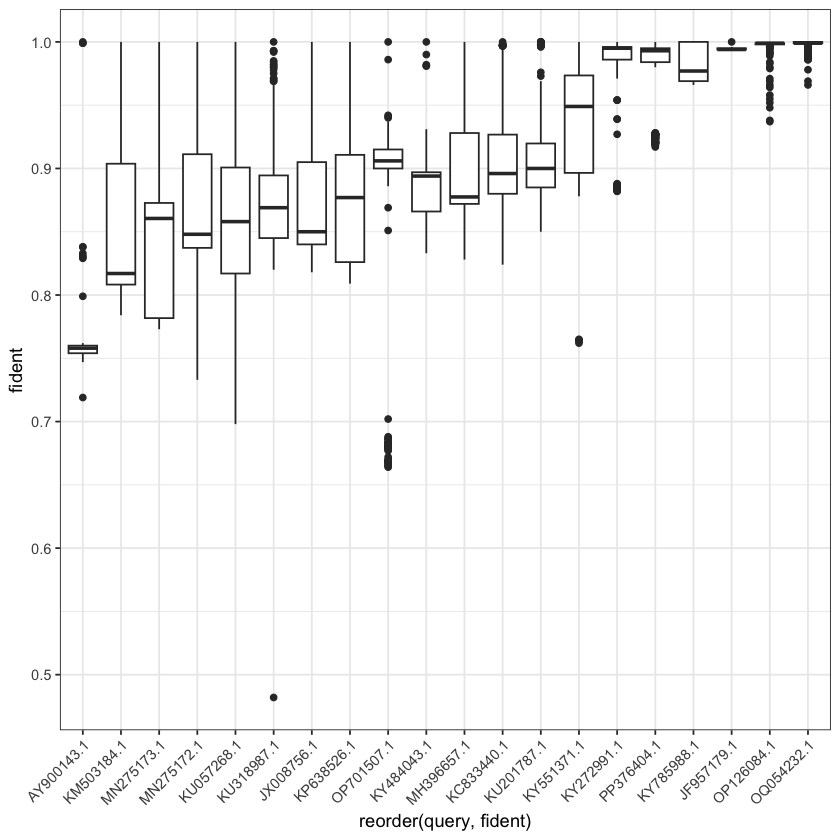

In [64]:
# Checking the observed diversity of references. (arrange with increasing mean fident)
ggplot(mmseqs, aes(y = fident, x = reorder(query, fident))) +
  geom_boxplot() +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

In [65]:
set.seed(42)
# Selecting a reference for each query in a window of [[80,82],[82,84],...,[98,100]]
selected_references <- mmseqs %>%
  filter(fident >=0.64) %>%
  mutate(fident_window = cut(fident, breaks = seq(0.64, 1, by = 0.02), include.lowest = TRUE)) %>%
  group_by(query, fident_window) %>%
  sample_n(size = 1, weight = alnlen)

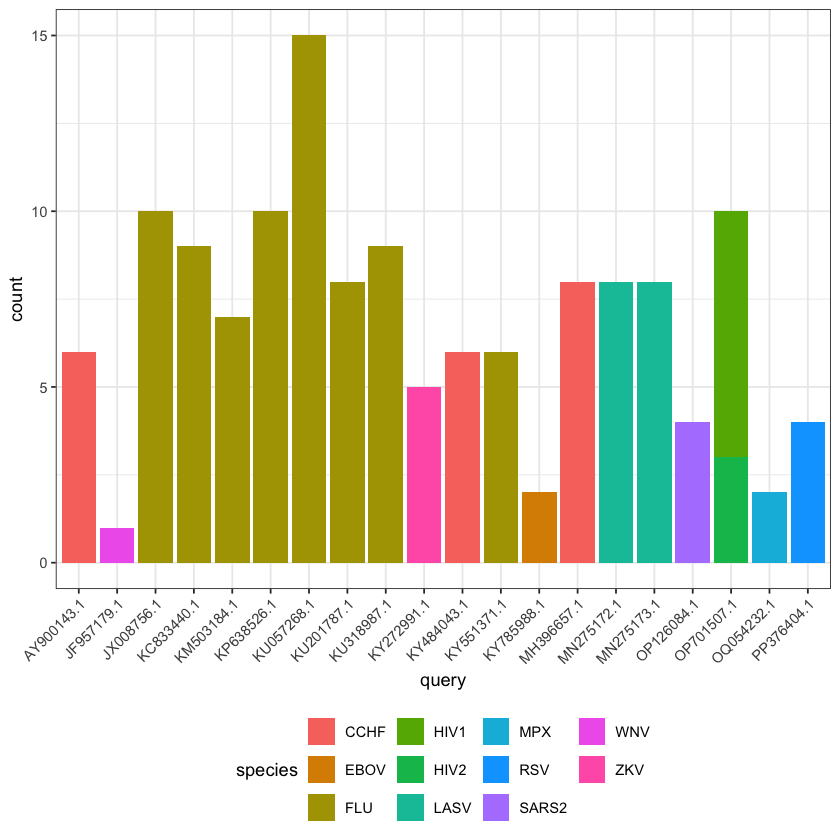

In [66]:
# Checking how many we have for every query
ggplot(selected_references, aes(x = query, fill = species)) +
  geom_bar() +
  theme_bw() +
  theme(legend.position = "bottom") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

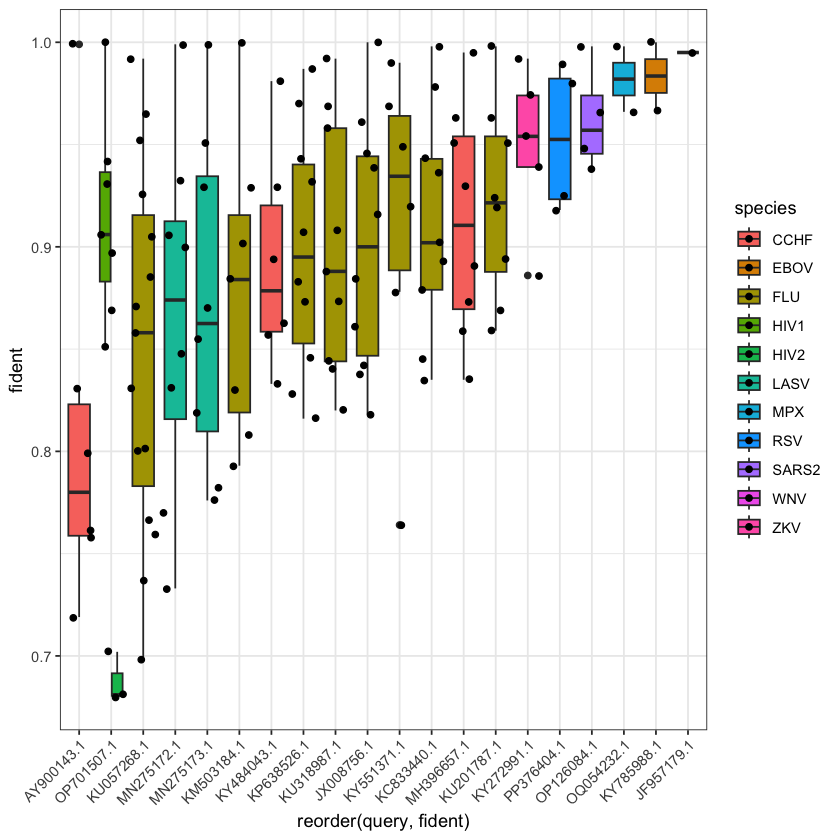

In [67]:
# Checking the observed diversity of references. (arrange with increasing mean fident)
ggplot(selected_references, aes(y = fident, x = reorder(query, fident), fill = species)) +
  geom_boxplot() +
  geom_jitter() +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

In [68]:
# Step 1 — helpers and expected segment counts
library(glue)
library(fs)
library(stringr)

fident_window_to_digits <- function(x) {
  rng <- str_match(as.character(x), "\\[?(0?\\.\\d+),\\s*(1|0?\\.\\d+)\\]")
  lo <- as.numeric(rng[, 2])
  hi <- as.numeric(rng[, 3])
  sprintf("%02d%02d", round(lo * 100), round(hi * 100))
}

out_dir <- "selected-references"
dir_create(out_dir)

In [76]:
collapse <- selected_references%>%
    group_by(species, fident_window)%>%
    summarise(targets_regex = paste(target,collapse = " " ))%>%
    ungroup()

apply(collapse, 1, function(x) {
    species <- x[1]
    fident_window <- x[2]
    targets_regex <- x[3]
    fident_digits <- fident_window_to_digits(fident_window)
    outname <- gsub(" ", "-", targets_regex)
    regex <- gsub(" ",")|(", targets_regex)
    out_file <- glue("{out_dir}/{fident_digits}_{outname}.fasta")
    command <- glue("cat ncbi-virus-fasta/sequences_*_{species}.fasta | seqkit grep -r -p '({regex})' > {out_file}")
    system(command)
})

`summarise()` has grouped output by 'species'. You can override using the
`.groups` argument.


[1] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[39] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

In [96]:
RVDB <- data.frame(
        sample = c("HIV", "LASV", "FLU", "CCHF", "EBOV", "MPX", "RSV", "SARS2", "WNV", "ZKV"),
        sequence = rep("/lustre1/project/stg_00132/databases/RVDB/U-RVDBv29.0.fasta", 10))%>%
    mutate(
        id= glue("{sample}-RVDB")
    )

    collapse%>%
        mutate(species = ifelse(grepl("HIV",species), "HIV", species))%>%
        mutate(
            id= glue("{species}-{fident_window_to_digits(fident_window)}"),
            sample = species,
            sequence = glue("data-preparation/{out_dir}/{fident_window_to_digits(fident_window)}_{gsub(' ', '-', targets_regex)}.fasta")
        )%>%
        select(id, sample, sequence)%>%
        bind_rows(., RVDB)%>%
        arrange(factor(species, levels=c("HIV","LASV", "FLU", "CCHF","EBOV","MPX","RSV","SARS2","WNV","ZKV")))%>%
        write_csv("../reference_pools.csv")

In [80]:
collapse%>%
    mutate(species = ifelse(grepl("HIV",species), "HIV", species))%>%
    mutate(
        sample= species,
        fastq_1 = glue("data-preparation/simulated-reads/{species}_R1.fastq.gz"),
        fastq_2 = glue("data-preparation/simulated-reads/{species}_R2.fastq.gz")
    )%>%
    select(sample, fastq_1, fastq_2)%>%
    unique()%>%
    write_csv("../samplesheet.csv")